# Trading Results â€” WNBA 2025 Holdout Backtest

Systematic evaluation of model-vs-market trading strategies across:
- **Models**: Elo-only, Full model (XGB + Elo)
- **Platforms**: Kalshi, Polymarket
- **Entry rules**: edge-only, edge + normalized edge, edge + normalized edge + confidence
- **Exit rules**: hold-to-settlement, sell-at-convergence
- **Sizing**: single unit ( fixed risk per trade), half-Kelly

All probabilities are P(home_win). Entry decision evaluated at the last
available quote/price before tipoff.

## 1. Setup

In [ ]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import log_loss, brier_score_loss
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline

PROJECT_ROOT = Path('../..').resolve()
GOLD_DIR     = PROJECT_ROOT / 'data' / 'gold'
KALSHI_DIR   = PROJECT_ROOT / 'data' / 'kalshi'
POLY_DIR     = PROJECT_ROOT / 'data' / 'polymarket'
OUT_DIR      = PROJECT_ROOT / 'data' / 'trading_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ┌─────────────────────────────────────────────────────────┐
# │  Final locked hyperparameters (Stage 3, rank 2)         │
# │  Source: organized/config/final_hyperparams.py          │
# │  max_depth=6  min_child_weight=3  gamma=0.1             │
# │  colsample_bytree=0.6  subsample=0.8  reg_lambda=1.0   │
# │  learning_rate=0.02                                     │
# └─────────────────────────────────────────────────────────┘
XGB_PARAMS = dict(
    objective='binary:logistic', eval_metric='logloss',
    max_depth=6, min_child_weight=3, subsample=0.8,
    colsample_bytree=0.6, reg_lambda=1.0, reg_alpha=0.0,
    gamma=0.1, learning_rate=0.02, seed=42, nthread=-1,
)
N_PLAYERS  = 7
MAX_ROUNDS = 3000
EARLY_STOP = 150
CLIP_EPS   = 1e-7
LABEL_COL  = 'home_win'
HALF_SPREAD_POLY = 0.03  # 2c half-spread for Polymarket mid-price execution

# --- Feature columns ---
PLAYER_FEATS = ['m_ewma_pre','q_pre','days_since_first_report_pre','days_since_last_dnp_pre',
                'consec_dnps_pre','played_last_game_pre','minutes_last_game_pre',
                'days_since_last_played_pre','injury_present_flag_pre']
FORM_FEATS   = ['net_rtg_ewma_pre','efg_ewma_pre','tov_pct_ewma_pre','orb_pct_ewma_pre','ftr_ewma_pre']
STYLE_FEATS  = ['off_3pa_rate_pre','def_3pa_allowed_pre','off_2pa_rate_pre','def_2pa_allowed_pre',
                'off_tov_pct_pre','def_forced_tov_pre']
SCHED_FEATS  = ['days_rest_pre','is_b2b_pre','games_last_4_days_pre','games_last_7_days_pre',
                'travel_miles_pre','timezone_shift_hours_pre']

def build_feature_cols(n):
    cols = [f'{s}_p{k}_{f}' for s in ('home','away') for k in range(1, n+1) for f in PLAYER_FEATS]
    for f in FORM_FEATS + STYLE_FEATS + SCHED_FEATS:
        cols += [f'home_{f}', f'away_{f}']
    return cols

FEAT_COLS = build_feature_cols(N_PLAYERS)

def clip(p): return np.clip(p, CLIP_EPS, 1 - CLIP_EPS)

def load_year(year):
    df = pd.read_csv(GOLD_DIR / f'game_xgboost_input_{year}_REGPST.csv')
    cold = (df['home_p1_m_ewma_pre'] == 0) | (df['away_p1_m_ewma_pre'] == 0)
    return df[~cold].reset_index(drop=True)

def make_dm(df, use_bm=True):
    avail = [c for c in FEAT_COLS if c in df.columns]
    y = df[LABEL_COL].values.astype(float) if LABEL_COL in df.columns else None
    dm = xgb.DMatrix(df[avail].values.astype(float), label=y,
                     feature_names=avail, missing=np.nan)
    if use_bm and 'base_margin' in df.columns:
        dm.set_base_margin(df['base_margin'].values.astype(float))
    return dm

print(f'Feature cols: {len(FEAT_COLS)}')
print('Setup complete.')

# --- Platform fee functions (taker, entry only) ---
import math

def kalshi_taker_fee(n_contracts, price):
    """Kalshi taker fee: round_up(0.07 * C * P * (1-P)), per-contract min $0.01."""
    raw = 0.07 * n_contracts * price * (1 - price)
    return math.ceil(raw * 100) / 100  # round up to next cent

def polymarket_taker_fee(n_contracts, price):
    """Polymarket sports taker fee: 0.03 * C * P * (1-P), rounded to 5 dp."""
    raw = 0.03 * n_contracts * price * (1 - price)
    return round(raw, 5)

def entry_fee(n_contracts, price, platform):
    """Compute taker fee at entry. No exit fees charged."""
    if platform == 'kalshi':
        return kalshi_taker_fee(n_contracts, price)
    elif platform == 'polymarket':
        return polymarket_taker_fee(n_contracts, price)
    return 0.0

# Quick sanity check against fee schedule
print('Fee sanity check (1 contract):')
for p in [0.10, 0.25, 0.50, 0.75, 0.90]:
    kf = kalshi_taker_fee(1, p)
    pf = polymarket_taker_fee(1, p)
    print(f'  P={p:.2f}  Kalshi=${kf:.2f}  Polymarket=${pf:.4f}')


Feature cols: 160
Setup complete.
Fee sanity check (1 contract):
  P=0.10  Kalshi=$0.01  Polymarket=$0.0027
  P=0.25  Kalshi=$0.02  Polymarket=$0.0056
  P=0.50  Kalshi=$0.02  Polymarket=$0.0075
  P=0.75  Kalshi=$0.02  Polymarket=$0.0056
  P=0.90  Kalshi=$0.01  Polymarket=$0.0027


## 2. Train Models & Build Signals

Train both the **full model** (XGB + Elo base margin) and produce
**Elo-only** predictions for the 2025 holdout.

In [112]:
# Load all gold data
all_data = {}
for yr in range(2015, 2026):
    all_data[yr] = load_year(yr)
    print(f'  {yr}: {len(all_data[yr])} rows')

test_2025 = all_data[2025]
es_tr     = pd.concat([all_data[yr] for yr in range(2015, 2024)], ignore_index=True)
val_df    = all_data[2024]
full_tr   = pd.concat([all_data[yr] for yr in range(2015, 2025)], ignore_index=True)

# --- Full model (XGB + Elo): early-stop on 2024, retrain on 2015-2024 ---
m_es = xgb.train(
    XGB_PARAMS, make_dm(es_tr), MAX_ROUNDS,
    evals=[(make_dm(val_df), 'val')],
    early_stopping_rounds=EARLY_STOP, verbose_eval=False,
)
best_round = m_es.best_iteration + 1
print(f'\nES best_round: {best_round}')

m_final = xgb.train(XGB_PARAMS, make_dm(full_tr), best_round, verbose_eval=False)
p_full_model = clip(m_final.predict(make_dm(test_2025)))

# --- Elo-only ---
p_elo = clip(test_2025['p_elo'].values.astype(float))

# --- Build game-level signal table ---
signals = test_2025[['game_id', 'game_ts', 'game_date',
                      'home_team_id', 'away_team_id', LABEL_COL]].copy()
signals['p_full_model'] = p_full_model
signals['p_elo']        = p_elo
signals['game_ts']      = pd.to_datetime(signals['game_ts'], utc=True)

y25 = test_2025[LABEL_COL].values.astype(float)
print(f'\nFull model 2025 log-loss: {log_loss(y25, p_full_model):.5f}')
print(f'Elo        2025 log-loss: {log_loss(y25, p_elo):.5f}')
print(f'Games: {len(signals)}')

  2015: 218 rows
  2016: 220 rows
  2017: 219 rows
  2018: 221 rows
  2019: 220 rows
  2020: 147 rows
  2021: 209 rows
  2022: 239 rows
  2023: 260 rows
  2024: 262 rows
  2025: 310 rows

ES best_round: 17

Full model 2025 log-loss: 0.61080
Elo        2025 log-loss: 0.61510
Games: 310


In [113]:
# --- Load ensemble predictions for confidence gate ---
ens_holdout = pd.read_csv(PROJECT_ROOT / 'data' / 'ensemble_comparison' / 'holdout_ensemble_comparison.csv')
ens_oof     = pd.read_csv(PROJECT_ROOT / 'data' / 'ensemble_comparison' / 'oof_ensemble_comparison.csv')

member_cols = [c for c in ens_holdout.columns if c.startswith('member_')]

# Compute per-game std dev across 10 ensemble members
ens_holdout['pred_std'] = ens_holdout[member_cols].std(axis=1)
ens_oof['pred_std']     = ens_oof[member_cols].std(axis=1)

# Confidence thresholds from OOF (training period) quantiles
STD_Q50 = ens_oof['pred_std'].quantile(0.50)
STD_Q65 = ens_oof['pred_std'].quantile(0.65)
STD_Q80 = ens_oof['pred_std'].quantile(0.80)

print(f'OOF pred_std quantiles:  Q50={STD_Q50:.4f}  Q65={STD_Q65:.4f}  Q80={STD_Q80:.4f}')
print(f'Holdout pred_std: mean={ens_holdout["pred_std"].mean():.4f}  median={ens_holdout["pred_std"].median():.4f}')

# Merge sigma into signals
signals = signals.merge(
    ens_holdout[['game_id', 'pred_std']],
    on='game_id', how='left',
)
print(f'Games with ensemble std: {signals["pred_std"].notna().sum()} / {len(signals)}')


OOF pred_std quantiles:  Q50=0.0191  Q65=0.0229  Q80=0.0282
Holdout pred_std: mean=0.0261  median=0.0245
Games with ensemble std: 310 / 310


## 3. Load Market Data & Build Entry Snapshots

In [114]:
# ============================================================
# 3A. Kalshi: home-team ticker mapping + entry snapshots
# ============================================================
k_matched = pd.read_csv(KALSHI_DIR / 'wnba_2025_game_markets_matched.csv')
k_markets = pd.read_csv(
    KALSHI_DIR / 'kalshi_markets.csv',
    usecols=['market_ticker', 'event_ticker', 'yes_sub_title', 'result'],
)
k_settle = pd.read_csv(
    KALSHI_DIR / 'kalshi_settlements.csv',
    usecols=['market_ticker', 'result', 'settlement_value_dollars'],
)

game_market_k = (
    k_matched[['event_ticker', 'game_id', 'team_a', 'team_a_id', 'team_b', 'team_b_id']]
    .merge(k_markets, on='event_ticker', how='inner')
)
game_market_k = game_market_k.merge(
    signals[['game_id', 'home_team_id', 'away_team_id', 'game_ts', 'pred_std',
             'p_full_model', 'p_elo', LABEL_COL]],
    on='game_id', how='inner',
)
game_market_k['ticker_team_id'] = np.where(
    game_market_k['yes_sub_title'] == game_market_k['team_a'],
    game_market_k['team_a_id'],
    game_market_k['team_b_id'],
)
game_market_k['is_home_ticker'] = game_market_k['ticker_team_id'] == game_market_k['home_team_id']
home_tickers_k = game_market_k[game_market_k['is_home_ticker']].drop_duplicates('game_id').copy()
home_tickers_k = home_tickers_k.merge(
    k_settle[['market_ticker', 'result']].rename(columns={'result': 'settle_result'}),
    on='market_ticker', how='left',
)
print(f'Kalshi: {len(home_tickers_k)} games with home-team ticker')

# --- Kalshi entry snapshots ---
home_ticker_set_k = set(home_tickers_k['market_ticker'])
candles = pd.read_csv(
    KALSHI_DIR / 'kalshi_candles_1m.csv',
    usecols=['market_ticker', 'end_period_ts', 'yes_bid_close', 'yes_ask_close'],
)
candles['ts'] = pd.to_datetime(candles['end_period_ts'], utc=True)
candles = candles[candles['market_ticker'].isin(home_ticker_set_k)].copy()
candles = candles.sort_values(['market_ticker', 'ts']).reset_index(drop=True)

ticker_info_k = home_tickers_k.set_index('market_ticker')[
    ['game_id', 'game_ts', 'p_full_model', 'p_elo', 'pred_std', LABEL_COL]
].to_dict('index')

kalshi_entry_rows = []
for ticker, info in ticker_info_k.items():
    tipoff = info['game_ts']
    entry_cutoff = tipoff - pd.Timedelta(minutes=5)
    sub = candles[(candles['market_ticker'] == ticker) & (candles['ts'] <= entry_cutoff)]
    if sub.empty:
        continue
    last = sub.iloc[-1]
    yb, ya = last['yes_bid_close'], last['yes_ask_close']
    if not (0 < yb < 1 and 0 < ya < 1):
        continue
    kalshi_entry_rows.append({
        'game_id':       info['game_id'],
        'platform':      'kalshi',
        'q_yes_exec':    ya,
        'q_no_exec':     1 - yb,
        'p_full_model':  info['p_full_model'],
        'p_elo':         info['p_elo'],
        'home_win':      info[LABEL_COL],
        'pred_std':      info.get('pred_std', np.nan),
    })

kalshi_entries = pd.DataFrame(kalshi_entry_rows)
print(f'Kalshi entry snapshots: {len(kalshi_entries)}')

Kalshi: 296 games with home-team ticker
Kalshi entry snapshots: 296


In [115]:
# ============================================================
# 3B. Polymarket: home-team token mapping + entry snapshots
# ============================================================
p_matched = pd.read_csv(POLY_DIR / 'wnba_2025_game_markets_matched.csv')

def team_pair_key(row, id_a_col, id_b_col, date_col):
    ids = sorted([str(row[id_a_col]), str(row[id_b_col])])
    return f"{ids[0]}_{ids[1]}_{row[date_col]}"

p_matched['match_key'] = p_matched.apply(
    lambda r: team_pair_key(r, 'team_a_id', 'team_b_id', 'game_date'), axis=1
)
signals['match_key'] = signals.apply(
    lambda r: team_pair_key(r, 'home_team_id', 'away_team_id', 'game_date'), axis=1
)

game_market_p = p_matched.merge(
    signals[['match_key', 'game_id', 'home_team_id', 'away_team_id', 'pred_std',
             'game_ts', 'p_full_model', 'p_elo', LABEL_COL]],
    on='match_key', how='inner', suffixes=('_poly', ''),
)
game_market_p['home_token_id'] = np.where(
    game_market_p['team_a_id'] == game_market_p['home_team_id'],
    game_market_p['team_a_token_id'],
    game_market_p['team_b_token_id'],
)
game_market_p['home_team_name'] = np.where(
    game_market_p['team_a_id'] == game_market_p['home_team_id'],
    game_market_p['team_a'],
    game_market_p['team_b'],
)
game_market_p['home_won_settle'] = (
    game_market_p['winner'] == game_market_p['home_team_name']
).astype(int)

home_tokens_p = game_market_p.drop_duplicates('match_key').copy()
home_tokens_p = home_tokens_p[home_tokens_p['winner'].notna()].copy()
settle_check = (home_tokens_p['home_won_settle'] == home_tokens_p[LABEL_COL])
home_tokens_p = home_tokens_p[settle_check].copy()
print(f'Polymarket: {len(home_tokens_p)} games with home-team token')

# --- Polymarket entry snapshots ---
home_token_set_p = set(home_tokens_p['home_token_id'])
prices = pd.read_csv(POLY_DIR / 'polymarket_prices_history.csv')
prices['ts'] = pd.to_datetime(prices['ts'], utc=True)
prices = prices[prices['token_id'].isin(home_token_set_p)].copy()
prices = prices.sort_values(['token_id', 'ts']).reset_index(drop=True)

token_info_p = home_tokens_p.set_index('home_token_id')[
    ['game_id', 'game_ts', 'p_full_model', 'p_elo', 'pred_std', LABEL_COL]
].to_dict('index')

poly_entry_rows = []
for token_id, info in token_info_p.items():
    tipoff = info['game_ts']
    entry_cutoff = tipoff - pd.Timedelta(minutes=5)
    sub = prices[(prices['token_id'] == token_id) & (prices['ts'] <= entry_cutoff)]
    if sub.empty:
        continue
    last = sub.iloc[-1]
    mid = last['price']
    if not (0 < mid < 1):
        continue
    q_yes = mid + HALF_SPREAD_POLY
    q_no  = (1 - mid) + HALF_SPREAD_POLY
    if q_yes >= 1.0 or q_no >= 1.0:
        continue
    poly_entry_rows.append({
        'game_id':       info['game_id'],
        'platform':      'polymarket',
        'q_yes_exec':    q_yes,
        'q_no_exec':     q_no,
        'p_full_model':  info['p_full_model'],
        'p_elo':         info['p_elo'],
        'home_win':      info[LABEL_COL],
        'pred_std':      info.get('pred_std', np.nan),
    })

poly_entries = pd.DataFrame(poly_entry_rows)
print(f'Polymarket entry snapshots: {len(poly_entries)}')

# --- Combine all entries ---
all_entries = pd.concat([kalshi_entries, poly_entries], ignore_index=True)
print(f'\nTotal entry snapshots: {len(all_entries)}')
print(all_entries.groupby('platform').size())

Polymarket: 277 games with home-team token
Polymarket entry snapshots: 277

Total entry snapshots: 573
platform
kalshi        296
polymarket    277
dtype: int64


## 4. Trading Engine

Hold-to-settlement backtest with configurable entry rules and sizing.

**Entry rules**:
- `edge_only`: trade if raw edge â‰¥ `edge_min`
- `edge_plus_normalized_edge`: trade if raw edge â‰¥ `edge_min` AND normalized edge â‰¥ `norm_edge_min`
- `edge_plus_normalized_edge_plus_confidence`: adds ensemble std gate

**Definitions**:
- Raw edge: `|p_model - p_market|`
- Normalized edge: `|p_model - p_market| / p_market` (relative to cost of the contract)
- p_market for YES side = `q_yes_exec`, for NO side = `q_no_exec`

In [116]:
UNIT_RISK = 1.0  # fixed dollar risk per trade

def run_settle_backtest(entries_df, model_col, edge_min,
                        norm_edge_min=None, std_max=None):
    """
    Hold-to-settlement backtest.
    Fixed $1 risk per trade. Taker fee charged at entry only.
    """
    trades = []
    for _, row in entries_df.iterrows():
        p        = row[model_col]
        q_yes    = row['q_yes_exec']
        q_no     = row['q_no_exec']
        hw       = row['home_win']
        game_id  = row['game_id']
        platform = row['platform']

        edge_yes = p - q_yes
        edge_no  = (1 - p) - q_no

        if edge_yes >= edge_no:
            side, entry_px, edge = 'YES', q_yes, edge_yes
        else:
            side, entry_px, edge = 'NO', q_no, edge_no

        if edge < edge_min:
            continue
        norm_edge = edge / entry_px if entry_px > 0 else 0
        if norm_edge_min is not None and norm_edge < norm_edge_min:
            continue
        if std_max is not None:
            pred_std = row.get('pred_std', np.nan)
            if pd.isna(pred_std) or pred_std > std_max:
                continue

        n_contracts = UNIT_RISK / entry_px
        fee = entry_fee(n_contracts, entry_px, platform)
        payout_per = 1.0 if (side == 'YES' and hw == 1) or (side == 'NO' and hw == 0) else 0.0
        revenue = n_contracts * payout_per
        pnl = revenue - UNIT_RISK - fee

        trades.append({
            'game_id':      game_id,
            'platform':     platform,
            'side':         side,
            'entry_px':     entry_px,
            'n_contracts':  round(n_contracts, 4),
            'edge':         edge,
            'norm_edge':    norm_edge,
            'fee':          round(fee, 4),
            'pnl':          pnl,
            'won':          int(payout_per == 1.0),
            'p_model':      p,
            'home_win':     hw,
        })

    return pd.DataFrame(trades)


def summarize_trades(tdf, label):
    if tdf.empty:
        return {'label': label, 'n_trades': 0, 'hit_rate': 0, 'mean_edge': 0,
                'mean_norm_edge': 0, 'total_pnl': 0, 'roi': 0, 'total_fees': 0}
    n = len(tdf)
    hit = tdf['won'].mean()
    total_pnl = tdf['pnl'].sum()
    total_fees = tdf['fee'].sum() if 'fee' in tdf.columns else 0
    roi = total_pnl / n
    return {
        'label':          label,
        'n_trades':       n,
        'hit_rate':       round(hit, 4),
        'mean_edge':      round(tdf['edge'].mean(), 4),
        'mean_norm_edge': round(tdf['norm_edge'].mean(), 4),
        'total_fees':     round(total_fees, 2),
        'total_pnl':      round(total_pnl, 2),
        'roi':            round(roi, 4),
    }

print('Trading engine defined (with fees).')


Trading engine defined (with fees).


## 5. Grid Search: All Entry Rule Combinations

Full grid over:
- `edge_min` âˆˆ {0.05, 0.10, 0.15}
- `norm_edge_min` âˆˆ {0, 0.10, 0.20, 0.25}  (0 = no normalized edge filter)
- `std_gate` âˆˆ {Q50, Q65, Q80, Q100}  (Q100 = no confidence filter)

Exit: **hold to settlement** | Sizing: **$1 fixed risk per trade**

One table per (model, platform) combination, sorted by ROI descending.

In [117]:
# --- Grid search parameters ---
EDGE_MINS     = [0.05, 0.10, 0.15]
NORM_EDGE_MINS = [0, 0.10, 0.20, 0.25]  # 0 = disabled
STD_GATES = {
    'Q50':  STD_Q50,
    'Q65':  STD_Q65,
    'Q80':  STD_Q80,
    'Q100': np.inf,  # no filter
}

grid_rows = []

for model_name, model_col in [('elo', 'p_elo'), ('full_model', 'p_full_model')]:
    for platform in ['kalshi', 'polymarket']:
        entries_sub = all_entries[all_entries['platform'] == platform].copy()
        for edge_min in EDGE_MINS:
            for norm_min in NORM_EDGE_MINS:
                for std_label, std_val in STD_GATES.items():
                    kw = dict(edge_min=edge_min)
                    if norm_min > 0:
                        kw['norm_edge_min'] = norm_min
                    if std_val < np.inf:
                        # Confidence gate only meaningful for full_model
                        if model_name == 'elo':
                            continue
                        kw['std_max'] = std_val

                    tdf = run_settle_backtest(entries_sub, model_col, **kw)
                    row = summarize_trades(tdf, '')
                    row['model']     = model_name
                    row['platform']  = platform
                    row['edge_min']  = edge_min
                    row['norm_min']  = norm_min
                    row['std_gate']  = std_label
                    grid_rows.append(row)

grid = pd.DataFrame(grid_rows)
grid.to_csv(OUT_DIR / 'grid_search_all.csv', index=False)
print(f'Grid search complete: {len(grid)} configurations')
print(f'  elo configs:        {(grid["model"]=="elo").sum()}')
print(f'  full_model configs: {(grid["model"]=="full_model").sum()}')


Grid search complete: 120 configurations
  elo configs:        24
  full_model configs: 96


In [118]:
# --- Display 4 tables: one per (model, platform), sorted by ROI ---
display_cols = ['edge_min', 'norm_min', 'std_gate', 'n_trades',
                'hit_rate', 'mean_edge', 'mean_norm_edge', 'total_fees', 'total_pnl', 'roi']

for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = grid[(grid['model'] == model_name) & (grid['platform'] == platform)].copy()
        sub = sub.sort_values('roi', ascending=False).reset_index(drop=True)
        print('=' * 110)
        print(f'  {model_name.upper()} / {platform.upper()}  '
              f'({len(sub)} configs, hold-to-settlement, $1 risk)')
        print('=' * 110)
        print(sub[display_cols].to_string(index=False))
        print()


  ELO / KALSHI  (12 configs, hold-to-settlement, $1 risk)
 edge_min  norm_min std_gate  n_trades  hit_rate  mean_edge  mean_norm_edge  total_fees  total_pnl    roi
     0.15      0.25     Q100        57    0.4035     0.2016          0.8318        3.04      20.32 0.3564
     0.15      0.10     Q100        59    0.4068     0.2000          0.8114        3.10      19.77 0.3351
     0.15      0.20     Q100        59    0.4068     0.2000          0.8114        3.10      19.77 0.3351
     0.15      0.00     Q100        59    0.4068     0.2000          0.8114        3.10      19.77 0.3351
     0.10      0.25     Q100        97    0.3608     0.1698          0.7047        5.28      15.99 0.1648
     0.05      0.10     Q100       177    0.3842     0.1310          0.5338        9.27      26.21 0.1481
     0.10      0.10     Q100       109    0.3853     0.1644          0.6501        5.69      15.42 0.1415
     0.10      0.00     Q100       109    0.3853     0.1644          0.6501        5.69      1

In [119]:
# --- Best config per (model, platform) ---
print('BEST CONFIGURATION PER MODEL x PLATFORM (by ROI):')
print('=' * 110)
best_rows = []
for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = grid[(grid['model'] == model_name) & (grid['platform'] == platform)]
        best = sub.sort_values('roi', ascending=False).iloc[0]
        best_rows.append(best)

best_df = pd.DataFrame(best_rows)
print(best_df[['model', 'platform', 'edge_min', 'norm_min', 'std_gate',
               'n_trades', 'hit_rate', 'total_pnl', 'roi']].to_string(index=False))

best_df.to_csv(OUT_DIR / 'grid_search_best.csv', index=False)


BEST CONFIGURATION PER MODEL x PLATFORM (by ROI):
     model   platform  edge_min  norm_min std_gate  n_trades  hit_rate  total_pnl    roi
       elo     kalshi      0.15      0.25     Q100        57    0.4035      20.32 0.3564
       elo polymarket      0.15      0.00     Q100        42    0.4286      19.42 0.4623
full_model     kalshi      0.15      0.20     Q100        54    0.4444      12.59 0.2331
full_model polymarket      0.15      0.00      Q80        16    0.5000       4.54 0.2838


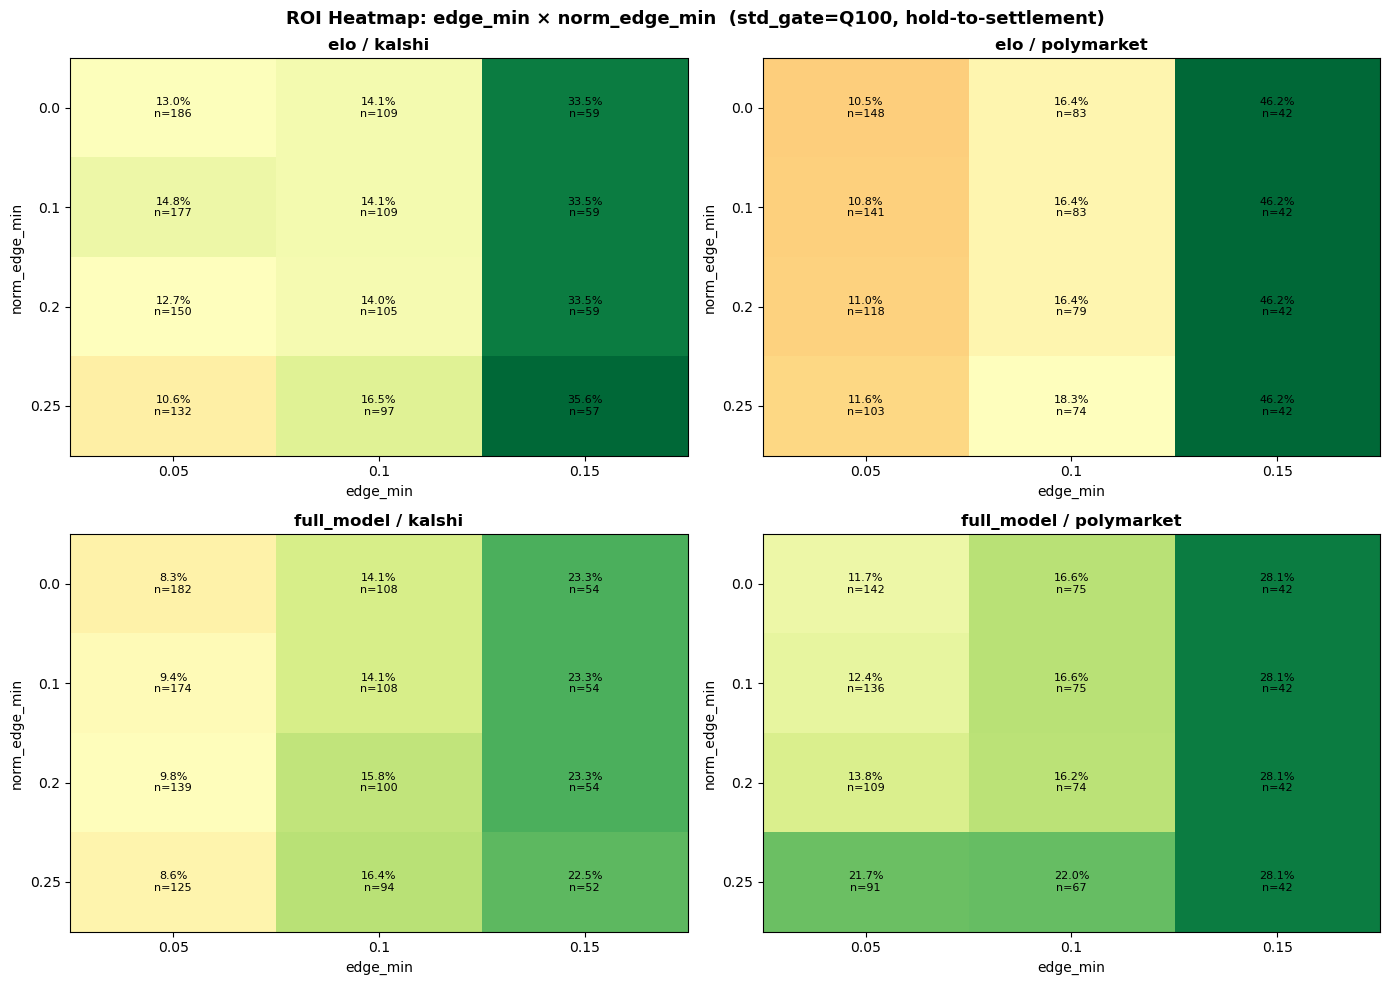

In [120]:
# --- Heatmap: ROI by edge_min x norm_min for each (model, platform) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

combos = [
    ('elo', 'kalshi'), ('elo', 'polymarket'),
    ('full_model', 'kalshi'), ('full_model', 'polymarket'),
]

for ax, (model_name, platform) in zip(axes.flat, combos):
    sub = grid[(grid['model'] == model_name) & (grid['platform'] == platform)
              & (grid['std_gate'] == 'Q100')].copy()  # no confidence filter for clean heatmap
    pivot = sub.pivot_table(index='norm_min', columns='edge_min', values='roi')
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                   vmin=min(-0.1, pivot.values.min()),
                   vmax=max(0.3, pivot.values.max()))
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('edge_min')
    ax.set_ylabel('norm_edge_min')
    ax.set_title(f'{model_name} / {platform}', fontweight='bold')
    # Annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            n_row = sub[(sub['edge_min'] == pivot.columns[j]) &
                        (sub['norm_min'] == pivot.index[i])]
            n = int(n_row['n_trades'].values[0]) if len(n_row) > 0 else 0
            ax.text(j, i, f'{val:.1%}\nn={n}', ha='center', va='center', fontsize=8)

plt.suptitle('ROI Heatmap: edge_min \u00d7 norm_edge_min  (std_gate=Q100, hold-to-settlement)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'grid_roi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Sell-at-Convergence Exit: Grid Search

Same entry grid as Section 5, but instead of holding to settlement,
exit when the market price reaches the modelâ€™s predicted probability.

- **Kalshi**: exit YES when `yes_bid >= p_model`, exit NO when `yes_ask <= p_model`
- **Polymarket**: exit YES when `mid - spread >= p_model`, exit NO when `mid + spread <= p_model`
- If no convergence occurs before settlement, hold to settlement as fallback.

In [121]:
# --- Build post-tipoff candle/price series for convergence monitoring ---

# Kalshi: post-tipoff candles keyed by market_ticker
post_tipoff_k = {}
for ticker, info in ticker_info_k.items():
    tipoff = info['game_ts']
    sub = candles[(candles['market_ticker'] == ticker) & (candles['ts'] > tipoff)].copy()
    if not sub.empty:
        post_tipoff_k[ticker] = sub[['ts', 'yes_bid_close', 'yes_ask_close']].reset_index(drop=True)

# Polymarket: post-tipoff prices keyed by home_token_id
post_tipoff_p = {}
for token_id, info in token_info_p.items():
    tipoff = info['game_ts']
    sub = prices[(prices['token_id'] == token_id) & (prices['ts'] > tipoff)].copy()
    if not sub.empty:
        post_tipoff_p[token_id] = sub[['ts', 'price']].reset_index(drop=True)

# Build ticker/token lookup from entries for convergence engine
# Kalshi: game_id -> market_ticker
game_to_ticker_k = dict(zip(
    home_tickers_k['game_id'], home_tickers_k['market_ticker']
))
# Polymarket: game_id -> home_token_id
game_to_token_p = dict(zip(
    home_tokens_p['game_id'], home_tokens_p['home_token_id']
))

print(f'Kalshi games with post-tipoff candles: {len(post_tipoff_k)}')
print(f'Polymarket games with post-tipoff prices: {len(post_tipoff_p)}')


Kalshi games with post-tipoff candles: 296
Polymarket games with post-tipoff prices: 277


In [122]:
def run_convergence_backtest(entries_df, model_col, edge_min,
                              norm_edge_min=None, std_max=None):
    """
    Convergence exit backtest. Fixed $1 risk. Taker fee at entry only.
    Exit via limit order (maker) = no exit fee.
    """
    trades = []
    for _, row in entries_df.iterrows():
        p        = row[model_col]
        q_yes    = row['q_yes_exec']
        q_no     = row['q_no_exec']
        hw       = row['home_win']
        game_id  = row['game_id']
        platform = row['platform']

        edge_yes = p - q_yes
        edge_no  = (1 - p) - q_no

        if edge_yes >= edge_no:
            side, entry_px, edge = 'YES', q_yes, edge_yes
        else:
            side, entry_px, edge = 'NO', q_no, edge_no

        if edge < edge_min:
            continue
        norm_edge = edge / entry_px if entry_px > 0 else 0
        if norm_edge_min is not None and norm_edge < norm_edge_min:
            continue
        if std_max is not None:
            pred_std = row.get('pred_std', np.nan)
            if pd.isna(pred_std) or pred_std > std_max:
                continue

        n_contracts = UNIT_RISK / entry_px
        fee = entry_fee(n_contracts, entry_px, platform)
        exit_type = 'settlement'
        exit_px = None

        if platform == 'kalshi':
            ticker = game_to_ticker_k.get(game_id)
            if ticker and ticker in post_tipoff_k:
                for _, c in post_tipoff_k[ticker].iterrows():
                    yb = c['yes_bid_close']
                    ya = c['yes_ask_close']
                    if not (0 < yb < 1 and 0 < ya < 1):
                        continue
                    if side == 'YES' and yb >= p:
                        exit_type, exit_px = 'converged', yb
                        break
                    elif side == 'NO' and ya <= p:
                        exit_type, exit_px = 'converged', 1 - ya
                        break

        elif platform == 'polymarket':
            token = game_to_token_p.get(game_id)
            if token and token in post_tipoff_p:
                for _, c in post_tipoff_p[token].iterrows():
                    mid = c['price']
                    if not (0 < mid < 1):
                        continue
                    if side == 'YES' and (mid - HALF_SPREAD_POLY) >= p:
                        exit_type, exit_px = 'converged', mid - HALF_SPREAD_POLY
                        break
                    elif side == 'NO' and (mid + HALF_SPREAD_POLY) <= p:
                        exit_type, exit_px = 'converged', (1 - mid) - HALF_SPREAD_POLY
                        break

        if exit_type == 'converged':
            pnl = n_contracts * (exit_px - entry_px) - fee
        else:
            payout_per = 1.0 if (side == 'YES' and hw == 1) or (side == 'NO' and hw == 0) else 0.0
            exit_px = payout_per
            pnl = n_contracts * (payout_per - entry_px) - fee

        trades.append({
            'game_id':      game_id,
            'platform':     platform,
            'side':         side,
            'entry_px':     entry_px,
            'n_contracts':  round(n_contracts, 4),
            'edge':         edge,
            'norm_edge':    norm_edge,
            'exit_type':    exit_type,
            'exit_px':      exit_px,
            'fee':          round(fee, 4),
            'pnl':          pnl,
            'won':          int(pnl > 0),
            'p_model':      p,
            'home_win':     hw,
        })

    return pd.DataFrame(trades)

print('Convergence engine defined (with fees).')


Convergence engine defined (with fees).


In [123]:
# --- Convergence grid search ---
conv_rows = []

for model_name, model_col in [('elo', 'p_elo'), ('full_model', 'p_full_model')]:
    for platform in ['kalshi', 'polymarket']:
        entries_sub = all_entries[all_entries['platform'] == platform].copy()
        for edge_min in EDGE_MINS:
            for norm_min in NORM_EDGE_MINS:
                for std_label, std_val in STD_GATES.items():
                    kw = dict(edge_min=edge_min)
                    if norm_min > 0:
                        kw['norm_edge_min'] = norm_min
                    if std_val < np.inf:
                        if model_name == 'elo':
                            continue
                        kw['std_max'] = std_val

                    tdf = run_convergence_backtest(entries_sub, model_col, **kw)
                    row = summarize_trades(tdf, '')
                    # Add convergence-specific stats
                    if not tdf.empty and 'exit_type' in tdf.columns:
                        n_conv = (tdf['exit_type'] == 'converged').sum()
                        n_sett = (tdf['exit_type'] == 'settlement').sum()
                        row['n_converged'] = n_conv
                        row['n_settlement'] = n_sett
                        row['conv_rate'] = round(n_conv / len(tdf), 4) if len(tdf) > 0 else 0
                    else:
                        row['n_converged'] = 0
                        row['n_settlement'] = 0
                        row['conv_rate'] = 0
                    row['model']     = model_name
                    row['platform']  = platform
                    row['edge_min']  = edge_min
                    row['norm_min']  = norm_min
                    row['std_gate']  = std_label
                    conv_rows.append(row)

conv_grid = pd.DataFrame(conv_rows)
conv_grid.to_csv(OUT_DIR / 'grid_search_convergence.csv', index=False)
print(f'Convergence grid search complete: {len(conv_grid)} configurations')


Convergence grid search complete: 120 configurations


In [124]:
# --- Display 4 tables: convergence exit, sorted by ROI ---
display_cols_c = ['edge_min', 'norm_min', 'std_gate', 'n_trades',
                  'n_converged', 'conv_rate', 'hit_rate',
                  'mean_edge', 'total_fees', 'total_pnl', 'roi']

for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = conv_grid[(conv_grid['model'] == model_name) &
                        (conv_grid['platform'] == platform)].copy()
        sub = sub.sort_values('roi', ascending=False).reset_index(drop=True)
        print('=' * 120)
        print(f'  {model_name.upper()} / {platform.upper()}  '
              f'({len(sub)} configs, CONVERGENCE EXIT, $1 risk)')
        print('=' * 120)
        print(sub[display_cols_c].to_string(index=False))
        print()


  ELO / KALSHI  (12 configs, CONVERGENCE EXIT, $1 risk)
 edge_min  norm_min std_gate  n_trades  n_converged  conv_rate  hit_rate  mean_edge  total_fees  total_pnl    roi
     0.10      0.25     Q100        97           65     0.6701    0.6701     0.1698        5.28      12.42 0.1280
     0.10      0.00     Q100       109           76     0.6972    0.6972     0.1644        5.69      13.74 0.1261
     0.10      0.10     Q100       109           76     0.6972    0.6972     0.1644        5.69      13.74 0.1261
     0.10      0.20     Q100       105           72     0.6857    0.6857     0.1664        5.55      13.00 0.1238
     0.15      0.25     Q100        57           35     0.6140    0.6140     0.2016        3.04       5.46 0.0958
     0.05      0.25     Q100       132           87     0.6591    0.6591     0.1455        7.49      11.74 0.0889
     0.05      0.20     Q100       150          102     0.6800    0.6800     0.1402        8.25      12.42 0.0828
     0.15      0.00     Q100    

In [125]:
# --- Best convergence config per (model, platform) ---
print('BEST CONVERGENCE CONFIG PER MODEL x PLATFORM (by ROI):')
print('=' * 120)
best_conv_rows = []
for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = conv_grid[(conv_grid['model'] == model_name) &
                        (conv_grid['platform'] == platform)]
        best = sub.sort_values('roi', ascending=False).iloc[0]
        best_conv_rows.append(best)

best_conv = pd.DataFrame(best_conv_rows)
print(best_conv[['model', 'platform', 'edge_min', 'norm_min', 'std_gate',
                 'n_trades', 'n_converged', 'conv_rate',
                 'hit_rate', 'total_pnl', 'roi']].to_string(index=False))

# --- Side-by-side: settlement vs convergence best ---
print('\n\n' + '=' * 120)
print('SETTLEMENT vs CONVERGENCE: best config comparison')
print('=' * 120)
for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        s = grid[(grid['model'] == model_name) & (grid['platform'] == platform)]
        c = conv_grid[(conv_grid['model'] == model_name) & (conv_grid['platform'] == platform)]
        s_best = s.sort_values('roi', ascending=False).iloc[0]
        c_best = c.sort_values('roi', ascending=False).iloc[0]
        print(f'\n{model_name} / {platform}:')
        print(f'  Settlement:  edge={s_best["edge_min"]}  norm={s_best["norm_min"]}  '
              f'std={s_best["std_gate"]}  n={int(s_best["n_trades"])}  '
              f'PnL={s_best["total_pnl"]:.1f}  ROI={s_best["roi"]:.1%}')
        print(f'  Convergence: edge={c_best["edge_min"]}  norm={c_best["norm_min"]}  '
              f'std={c_best["std_gate"]}  n={int(c_best["n_trades"])}  '
              f'PnL={c_best["total_pnl"]:.1f}  ROI={c_best["roi"]:.1%}')


BEST CONVERGENCE CONFIG PER MODEL x PLATFORM (by ROI):
     model   platform  edge_min  norm_min std_gate  n_trades  n_converged  conv_rate  hit_rate  total_pnl    roi
       elo     kalshi      0.10      0.25     Q100        97           65     0.6701    0.6701      12.42 0.1280
       elo polymarket      0.05      0.25     Q100       103           78     0.7573    0.7573      50.91 0.4943
full_model     kalshi      0.10      0.20      Q50        18           12     0.6667    0.6667       3.82 0.2123
full_model polymarket      0.15      0.00      Q50         4            4     1.0000    1.0000       5.68 1.4198


SETTLEMENT vs CONVERGENCE: best config comparison

elo / kalshi:
  Settlement:  edge=0.15  norm=0.25  std=Q100  n=57  PnL=20.3  ROI=35.6%
  Convergence: edge=0.1  norm=0.25  std=Q100  n=97  PnL=12.4  ROI=12.8%

elo / polymarket:
  Settlement:  edge=0.15  norm=0.0  std=Q100  n=42  PnL=19.4  ROI=46.2%
  Convergence: edge=0.05  norm=0.25  std=Q100  n=103  PnL=50.9  ROI=49.4%

fu

## 7. Equity Curves

Cumulative PnL over the 2025 season for the best config per (model, platform, exit rule).
Since each trade risks $1, cumulative PnL at trade N equals total profit on $N deployed.

- **Solid** = hold-to-settlement, **Dotted** = sell-at-convergence
- Colors distinguish platforms

In [126]:
# --- Regenerate trades for best configs and build equity curves ---

# Get game dates for ordering
game_dates = signals.set_index('game_id')['game_date'].to_dict()

def get_best_config(grid_df, model, platform):
    sub = grid_df[(grid_df['model'] == model) & (grid_df['platform'] == platform)]
    return sub.sort_values('roi', ascending=False).iloc[0]

def run_and_sort(entries_sub, model_col, kw, engine_func):
    """Run backtest and return trades sorted by game date."""
    tdf = engine_func(entries_sub, model_col, **kw)
    if tdf.empty:
        return tdf
    tdf['game_date'] = tdf['game_id'].map(game_dates)
    tdf['game_date'] = pd.to_datetime(tdf['game_date'])
    return tdf.sort_values('game_date').reset_index(drop=True)

def build_kw(row):
    kw = dict(edge_min=row['edge_min'])
    if row['norm_min'] > 0:
        kw['norm_edge_min'] = row['norm_min']
    if row['std_gate'] != 'Q100':
        kw['std_max'] = STD_GATES[row['std_gate']]
    return kw

# Build all 8 equity curves (2 models x 2 platforms x 2 exit rules)
equity_curves = {}

for model_name, model_col in [('elo', 'p_elo'), ('full_model', 'p_full_model')]:
    for platform in ['kalshi', 'polymarket']:
        entries_sub = all_entries[all_entries['platform'] == platform].copy()

        # Settlement best
        best_s = get_best_config(grid, model_name, platform)
        kw_s = build_kw(best_s)
        tdf_s = run_and_sort(entries_sub, model_col, kw_s, run_settle_backtest)

        # Convergence best
        best_c = get_best_config(conv_grid, model_name, platform)
        kw_c = build_kw(best_c)
        tdf_c = run_and_sort(entries_sub, model_col, kw_c, run_convergence_backtest)

        key = (model_name, platform)
        equity_curves[key] = {
            'settle': tdf_s, 'converge': tdf_c,
            'best_s': best_s, 'best_c': best_c,
        }

print('Equity curves built for all 8 combinations.')


Equity curves built for all 8 combinations.


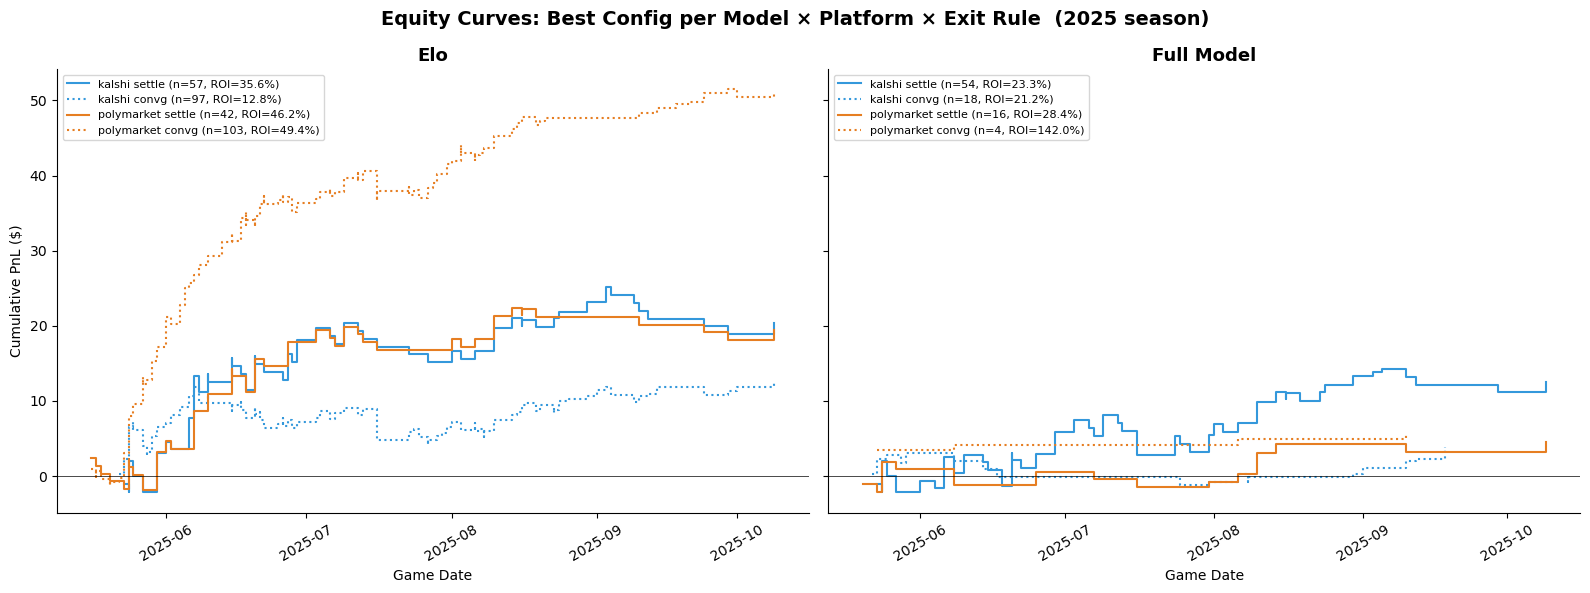

In [127]:
# --- Plot: 2 axes (elo, full_model), 2 colors (kalshi, polymarket), 2 styles (solid, dotted) ---
PLATFORM_COLORS = {'kalshi': '#3498db', 'polymarket': '#e67e22'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, ['elo', 'full_model']):
    for platform in ['kalshi', 'polymarket']:
        color = PLATFORM_COLORS[platform]
        ec = equity_curves[(model_name, platform)]

        # Settlement (solid)
        tdf_s = ec['settle']
        if not tdf_s.empty:
            cum_pnl_s = tdf_s['pnl'].cumsum()
            ax.step(tdf_s['game_date'], cum_pnl_s, where='post',
                    color=color, linestyle='-', linewidth=1.5,
                    label=f'{platform} settle (n={len(tdf_s)}, ROI={ec["best_s"]["roi"]:.1%})')

        # Convergence (dotted)
        tdf_c = ec['converge']
        if not tdf_c.empty:
            cum_pnl_c = tdf_c['pnl'].cumsum()
            ax.step(tdf_c['game_date'], cum_pnl_c, where='post',
                    color=color, linestyle=':', linewidth=1.5,
                    label=f'{platform} convg (n={len(tdf_c)}, ROI={ec["best_c"]["roi"]:.1%})')

    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Game Date')
    ax.set_title(f'{model_name.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Cumulative PnL ($)')

plt.suptitle('Equity Curves: Best Config per Model \u00d7 Platform \u00d7 Exit Rule  (2025 season)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Half-Kelly Sizing

Replace fixed $1 risk with **half-Kelly** bet sizing.

For a binary contract at price $q$ with model probability $p$:

$$f^* = \frac{p - q}{1 - q}$$

This is the full Kelly fraction of bankroll to wager. We use **half-Kelly** ($f^*/2$)
for conservatism. The dollar risk per trade is `(f*/2) * bankroll`.

Starting bankroll: $100. Bankroll updates after each trade (compounding).

In [128]:
BANKROLL_INIT = 100.0

def run_kelly_settle(entries_df, model_col, edge_min,
                     norm_edge_min=None, std_max=None):
    """
    Hold-to-settlement with half-Kelly sizing. Taker fee at entry only.
    """
    df = entries_df.copy()
    df['game_date'] = df['game_id'].map(
        signals.set_index('game_id')['game_date'].to_dict()
    )
    df = df.sort_values('game_date').reset_index(drop=True)

    bankroll = BANKROLL_INIT
    trades = []

    for _, row in df.iterrows():
        p        = row[model_col]
        q_yes    = row['q_yes_exec']
        q_no     = row['q_no_exec']
        hw       = row['home_win']
        game_id  = row['game_id']
        platform = row['platform']

        edge_yes = p - q_yes
        edge_no  = (1 - p) - q_no

        if edge_yes >= edge_no:
            side, entry_px, edge = 'YES', q_yes, edge_yes
            p_side = p
        else:
            side, entry_px, edge = 'NO', q_no, edge_no
            p_side = 1 - p

        if edge < edge_min:
            continue
        norm_edge = edge / entry_px if entry_px > 0 else 0
        if norm_edge_min is not None and norm_edge < norm_edge_min:
            continue
        if std_max is not None:
            pred_std = row.get('pred_std', np.nan)
            if pd.isna(pred_std) or pred_std > std_max:
                continue

        kelly_f = max((p_side - entry_px) / (1 - entry_px), 0)
        wager = (kelly_f / 2) * bankroll
        if wager < 0.01:
            continue

        n_contracts = wager / entry_px
        fee = entry_fee(n_contracts, entry_px, platform)
        payout_per = 1.0 if (side == 'YES' and hw == 1) or (side == 'NO' and hw == 0) else 0.0
        revenue = n_contracts * payout_per
        pnl = revenue - wager - fee
        bankroll += pnl

        trades.append({
            'game_id':      game_id,
            'game_date':    row['game_date'],
            'platform':     platform,
            'side':         side,
            'entry_px':     entry_px,
            'kelly_f':      round(kelly_f, 4),
            'wager':        round(wager, 2),
            'n_contracts':  round(n_contracts, 4),
            'edge':         edge,
            'norm_edge':    norm_edge,
            'fee':          round(fee, 4),
            'pnl':          pnl,
            'won':          int(payout_per == 1.0),
            'bankroll':     round(bankroll, 2),
            'p_model':      p,
            'home_win':     hw,
        })

    return pd.DataFrame(trades)


def run_kelly_convergence(entries_df, model_col, edge_min,
                          norm_edge_min=None, std_max=None):
    """
    Convergence exit with half-Kelly sizing. Taker fee at entry only.
    """
    df = entries_df.copy()
    df['game_date'] = df['game_id'].map(
        signals.set_index('game_id')['game_date'].to_dict()
    )
    df = df.sort_values('game_date').reset_index(drop=True)

    bankroll = BANKROLL_INIT
    trades = []

    for _, row in df.iterrows():
        p        = row[model_col]
        q_yes    = row['q_yes_exec']
        q_no     = row['q_no_exec']
        hw       = row['home_win']
        game_id  = row['game_id']
        platform = row['platform']

        edge_yes = p - q_yes
        edge_no  = (1 - p) - q_no

        if edge_yes >= edge_no:
            side, entry_px, edge = 'YES', q_yes, edge_yes
            p_side = p
        else:
            side, entry_px, edge = 'NO', q_no, edge_no
            p_side = 1 - p

        if edge < edge_min:
            continue
        norm_edge = edge / entry_px if entry_px > 0 else 0
        if norm_edge_min is not None and norm_edge < norm_edge_min:
            continue
        if std_max is not None:
            pred_std = row.get('pred_std', np.nan)
            if pd.isna(pred_std) or pred_std > std_max:
                continue

        kelly_f = max((p_side - entry_px) / (1 - entry_px), 0)
        wager = (kelly_f / 2) * bankroll
        if wager < 0.01:
            continue

        n_contracts = wager / entry_px
        fee = entry_fee(n_contracts, entry_px, platform)
        exit_type = 'settlement'
        exit_px = None

        if platform == 'kalshi':
            ticker = game_to_ticker_k.get(game_id)
            if ticker and ticker in post_tipoff_k:
                for _, c in post_tipoff_k[ticker].iterrows():
                    yb, ya = c['yes_bid_close'], c['yes_ask_close']
                    if not (0 < yb < 1 and 0 < ya < 1):
                        continue
                    if side == 'YES' and yb >= p:
                        exit_type, exit_px = 'converged', yb
                        break
                    elif side == 'NO' and ya <= p:
                        exit_type, exit_px = 'converged', 1 - ya
                        break
        elif platform == 'polymarket':
            token = game_to_token_p.get(game_id)
            if token and token in post_tipoff_p:
                for _, c in post_tipoff_p[token].iterrows():
                    mid = c['price']
                    if not (0 < mid < 1):
                        continue
                    if side == 'YES' and (mid - HALF_SPREAD_POLY) >= p:
                        exit_type, exit_px = 'converged', mid - HALF_SPREAD_POLY
                        break
                    elif side == 'NO' and (mid + HALF_SPREAD_POLY) <= p:
                        exit_type, exit_px = 'converged', (1 - mid) - HALF_SPREAD_POLY
                        break

        if exit_type == 'converged':
            pnl = n_contracts * (exit_px - entry_px) - fee
        else:
            payout_per = 1.0 if (side == 'YES' and hw == 1) or (side == 'NO' and hw == 0) else 0.0
            exit_px = payout_per
            pnl = n_contracts * (payout_per - entry_px) - fee

        bankroll += pnl

        trades.append({
            'game_id':      game_id,
            'game_date':    row['game_date'],
            'platform':     platform,
            'side':         side,
            'entry_px':     entry_px,
            'kelly_f':      round(kelly_f, 4),
            'wager':        round(wager, 2),
            'n_contracts':  round(n_contracts, 4),
            'edge':         edge,
            'norm_edge':    norm_edge,
            'exit_type':    exit_type,
            'fee':          round(fee, 4),
            'pnl':          pnl,
            'won':          int(pnl > 0),
            'bankroll':     round(bankroll, 2),
            'p_model':      p,
            'home_win':     hw,
        })

    return pd.DataFrame(trades)


def summarize_kelly(tdf, label):
    if tdf.empty:
        return {'label': label, 'n_trades': 0, 'hit_rate': 0,
                'total_pnl': 0, 'final_bankroll': BANKROLL_INIT, 'total_return': 0,
                'mean_edge': 0, 'mean_kelly_f': 0, 'mean_wager': 0, 'total_fees': 0}
    n = len(tdf)
    final = tdf['bankroll'].iloc[-1]
    total_fees = tdf['fee'].sum() if 'fee' in tdf.columns else 0
    return {
        'label':           label,
        'n_trades':        n,
        'hit_rate':        round(tdf['won'].mean(), 4),
        'mean_edge':       round(tdf['edge'].mean(), 4),
        'mean_kelly_f':    round(tdf['kelly_f'].mean(), 4),
        'mean_wager':      round(tdf['wager'].mean(), 2),
        'total_fees':      round(total_fees, 2),
        'total_pnl':       round(tdf['pnl'].sum(), 2),
        'final_bankroll':  round(final, 2),
        'total_return':    round((final - BANKROLL_INIT) / BANKROLL_INIT, 4),
        'max_drawdown':    round(
            (tdf['bankroll'].cummax() - tdf['bankroll']).max(), 2
        ),
    }

print(f'Half-Kelly engines defined (with fees). Starting bankroll: ${BANKROLL_INIT}')


Half-Kelly engines defined (with fees). Starting bankroll: $100.0


In [129]:
# --- Half-Kelly grid search: settlement ---
kelly_s_rows = []
for model_name, model_col in [('elo', 'p_elo'), ('full_model', 'p_full_model')]:
    for platform in ['kalshi', 'polymarket']:
        entries_sub = all_entries[all_entries['platform'] == platform].copy()
        for edge_min in EDGE_MINS:
            for norm_min in NORM_EDGE_MINS:
                for std_label, std_val in STD_GATES.items():
                    kw = dict(edge_min=edge_min)
                    if norm_min > 0:
                        kw['norm_edge_min'] = norm_min
                    if std_val < np.inf:
                        if model_name == 'elo':
                            continue
                        kw['std_max'] = std_val
                    tdf = run_kelly_settle(entries_sub, model_col, **kw)
                    row = summarize_kelly(tdf, '')
                    row['model'] = model_name
                    row['platform'] = platform
                    row['edge_min'] = edge_min
                    row['norm_min'] = norm_min
                    row['std_gate'] = std_label
                    row['exit'] = 'settlement'
                    kelly_s_rows.append(row)

kelly_settle = pd.DataFrame(kelly_s_rows)
print(f'Kelly settlement grid: {len(kelly_settle)} configs')

# --- Half-Kelly grid search: convergence ---
kelly_c_rows = []
for model_name, model_col in [('elo', 'p_elo'), ('full_model', 'p_full_model')]:
    for platform in ['kalshi', 'polymarket']:
        entries_sub = all_entries[all_entries['platform'] == platform].copy()
        for edge_min in EDGE_MINS:
            for norm_min in NORM_EDGE_MINS:
                for std_label, std_val in STD_GATES.items():
                    kw = dict(edge_min=edge_min)
                    if norm_min > 0:
                        kw['norm_edge_min'] = norm_min
                    if std_val < np.inf:
                        if model_name == 'elo':
                            continue
                        kw['std_max'] = std_val
                    tdf = run_kelly_convergence(entries_sub, model_col, **kw)
                    row = summarize_kelly(tdf, '')
                    row['model'] = model_name
                    row['platform'] = platform
                    row['edge_min'] = edge_min
                    row['norm_min'] = norm_min
                    row['std_gate'] = std_label
                    row['exit'] = 'convergence'
                    kelly_c_rows.append(row)

kelly_conv = pd.DataFrame(kelly_c_rows)
print(f'Kelly convergence grid: {len(kelly_conv)} configs')

kelly_all = pd.concat([kelly_settle, kelly_conv], ignore_index=True)
kelly_all.to_csv(OUT_DIR / 'grid_search_kelly.csv', index=False)


Kelly settlement grid: 120 configs
Kelly convergence grid: 120 configs


In [130]:
# --- Half-Kelly tables: settlement ---
kelly_disp = ['edge_min', 'norm_min', 'std_gate', 'n_trades', 'hit_rate',
              'mean_edge', 'mean_kelly_f', 'mean_wager',
              'total_pnl', 'final_bankroll', 'total_return', 'max_drawdown']

print('\n' + '#' * 120)
print('  HALF-KELLY: HOLD-TO-SETTLEMENT')
print('#' * 120)
for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = kelly_settle[(kelly_settle['model'] == model_name) &
                           (kelly_settle['platform'] == platform)].copy()
        sub = sub.sort_values('total_return', ascending=False).reset_index(drop=True)
        print('\n' + '=' * 120)
        print(f'  {model_name.upper()} / {platform.upper()}  '
              f'(half-Kelly, settlement, starting ${BANKROLL_INIT})')
        print('=' * 120)
        print(sub[kelly_disp].to_string(index=False))



########################################################################################################################
  HALF-KELLY: HOLD-TO-SETTLEMENT
########################################################################################################################

  ELO / KALSHI  (half-Kelly, settlement, starting $100.0)
 edge_min  norm_min std_gate  n_trades  hit_rate  mean_edge  mean_kelly_f  mean_wager  total_pnl  final_bankroll  total_return  max_drawdown
     0.15      0.25     Q100        57    0.4035     0.2016        0.3082       52.32     223.67          323.67        2.2367        615.53
     0.15      0.10     Q100        59    0.4068     0.2000        0.3132       48.16     176.10          276.10        1.7610        525.08
     0.15      0.20     Q100        59    0.4068     0.2000        0.3132       48.16     176.10          276.10        1.7610        525.08
     0.15      0.00     Q100        59    0.4068     0.2000        0.3132       48.16     176.10     

In [131]:
# --- Half-Kelly tables: convergence ---
print('\n' + '#' * 120)
print('  HALF-KELLY: SELL-AT-CONVERGENCE')
print('#' * 120)
for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = kelly_conv[(kelly_conv['model'] == model_name) &
                         (kelly_conv['platform'] == platform)].copy()
        sub = sub.sort_values('total_return', ascending=False).reset_index(drop=True)
        print('\n' + '=' * 120)
        print(f'  {model_name.upper()} / {platform.upper()}  '
              f'(half-Kelly, convergence, starting ${BANKROLL_INIT})')
        print('=' * 120)
        print(sub[kelly_disp].to_string(index=False))



########################################################################################################################
  HALF-KELLY: SELL-AT-CONVERGENCE
########################################################################################################################

  ELO / KALSHI  (half-Kelly, convergence, starting $100.0)
 edge_min  norm_min std_gate  n_trades  hit_rate  mean_edge  mean_kelly_f  mean_wager  total_pnl  final_bankroll  total_return  max_drawdown
     0.05      0.10     Q100       177    0.7119     0.1310        0.2093       16.38     142.99          242.99        1.4299        193.01
     0.10      0.00     Q100       109    0.6972     0.1644        0.2596       20.67     137.98          237.98        1.3798        226.06
     0.10      0.10     Q100       109    0.6972     0.1644        0.2596       20.67     137.98          237.98        1.3798        226.06
     0.05      0.00     Q100       186    0.7204     0.1275        0.2097       15.75     123.77   

In [132]:
# --- Best half-Kelly config per (model, platform, exit) ---
print('BEST HALF-KELLY CONFIGS (by total return):')
print('=' * 130)
best_kelly = []
for exit_name, gdf in [('settlement', kelly_settle), ('convergence', kelly_conv)]:
    for model_name in ['elo', 'full_model']:
        for platform in ['kalshi', 'polymarket']:
            sub = gdf[(gdf['model'] == model_name) & (gdf['platform'] == platform)]
            best = sub.sort_values('total_return', ascending=False).iloc[0].copy()
            best['exit'] = exit_name
            best_kelly.append(best)

best_kelly_df = pd.DataFrame(best_kelly)
print(best_kelly_df[['model', 'platform', 'exit', 'edge_min', 'norm_min', 'std_gate',
                     'n_trades', 'hit_rate', 'final_bankroll',
                     'total_return', 'max_drawdown']].to_string(index=False))


BEST HALF-KELLY CONFIGS (by total return):
     model   platform        exit  edge_min  norm_min std_gate  n_trades  hit_rate  final_bankroll  total_return  max_drawdown
       elo     kalshi  settlement      0.15      0.25     Q100        57    0.4035          323.67        2.2367        615.53
       elo polymarket  settlement      0.15      0.00     Q100        42    0.4286          370.20        2.7020        384.14
full_model     kalshi  settlement      0.15      0.20     Q100        54    0.4444          286.94        1.8694        227.36
full_model polymarket  settlement      0.05      0.25     Q100        91    0.3407          299.21        1.9921        291.22
       elo     kalshi convergence      0.05      0.10     Q100       177    0.7119          242.99        1.4299        193.01
       elo polymarket convergence      0.05      0.00     Q100       148    0.7905         1856.59       17.5659        570.22
full_model     kalshi convergence      0.10      0.10      Q80      

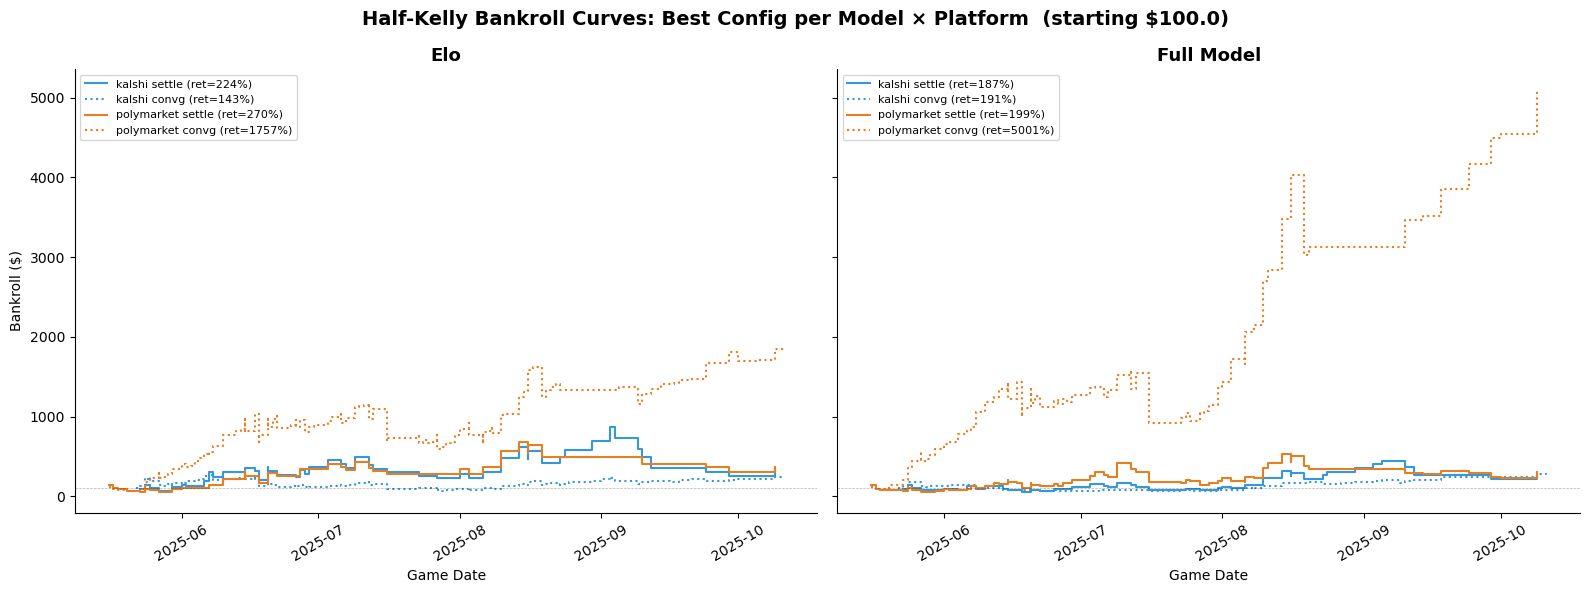

In [133]:
# --- Half-Kelly equity curves: bankroll over time ---
PLATFORM_COLORS = {'kalshi': '#3498db', 'polymarket': '#e67e22'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_name, model_col in zip(axes,
        ['elo', 'full_model'], ['p_elo', 'p_full_model']):
    for platform in ['kalshi', 'polymarket']:
        color = PLATFORM_COLORS[platform]
        entries_sub = all_entries[all_entries['platform'] == platform].copy()

        # Best settlement config
        best_s = kelly_settle[(kelly_settle['model'] == model_name) &
                              (kelly_settle['platform'] == platform)] \
                    .sort_values('total_return', ascending=False).iloc[0]
        kw_s = dict(edge_min=best_s['edge_min'])
        if best_s['norm_min'] > 0:
            kw_s['norm_edge_min'] = best_s['norm_min']
        if best_s['std_gate'] != 'Q100':
            kw_s['std_max'] = STD_GATES[best_s['std_gate']]
        tdf_s = run_kelly_settle(entries_sub, model_col, **kw_s)

        if not tdf_s.empty:
            tdf_s['game_date'] = pd.to_datetime(tdf_s['game_date'])
            ax.step(tdf_s['game_date'], tdf_s['bankroll'], where='post',
                    color=color, linestyle='-', linewidth=1.5,
                    label=f'{platform} settle (ret={best_s["total_return"]:.0%})')

        # Best convergence config
        best_c = kelly_conv[(kelly_conv['model'] == model_name) &
                            (kelly_conv['platform'] == platform)] \
                    .sort_values('total_return', ascending=False).iloc[0]
        kw_c = dict(edge_min=best_c['edge_min'])
        if best_c['norm_min'] > 0:
            kw_c['norm_edge_min'] = best_c['norm_min']
        if best_c['std_gate'] != 'Q100':
            kw_c['std_max'] = STD_GATES[best_c['std_gate']]
        tdf_c = run_kelly_convergence(entries_sub, model_col, **kw_c)

        if not tdf_c.empty:
            tdf_c['game_date'] = pd.to_datetime(tdf_c['game_date'])
            ax.step(tdf_c['game_date'], tdf_c['bankroll'], where='post',
                    color=color, linestyle=':', linewidth=1.5,
                    label=f'{platform} convg (ret={best_c["total_return"]:.0%})')

    ax.axhline(BANKROLL_INIT, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_xlabel('Game Date')
    ax.set_title(f'{model_name.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Bankroll ($)')

plt.suptitle(f'Half-Kelly Bankroll Curves: Best Config per Model \u00d7 Platform  '
             f'(starting ${BANKROLL_INIT})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'kelly_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Pre-Tipoff Convergence

A cleaner convergence strategy that restricts **all activity to pre-game prices only**:

- **Entry window**: scan from T-12 h to tipoff, checking every **15 minutes**
- **Entry rule**: same edge / norm-edge / std gates as before — enter at first qualifying snapshot
- **Convergence window**: once entered, check every **1 minute** until tipoff
- **Convergence trigger**: market reaches model price (same logic as Section 6, but pre-tipoff only)
- **Fallback**: if no convergence by tipoff, hold to settlement

This avoids the in-game volatility inflation that contaminates the post-tipoff convergence results.

In [142]:
# --- Build pre-tipoff price series (T-12h to tipoff) for both platforms ---
ENTRY_WINDOW_H = 12          # hours before tipoff to start scanning

# Kalshi: pre-tipoff candles keyed by market_ticker
pretip_k = {}
for ticker, info in ticker_info_k.items():
    tipoff = info['game_ts']
    window_start = tipoff - pd.Timedelta(hours=ENTRY_WINDOW_H)
    sub = candles[(candles['market_ticker'] == ticker) &
                  (candles['ts'] >= window_start) &
                  (candles['ts'] <= tipoff)].copy()
    if not sub.empty:
        pretip_k[ticker] = sub[['ts', 'yes_bid_close', 'yes_ask_close']].reset_index(drop=True)

# Polymarket: pre-tipoff prices keyed by home_token_id
pretip_p = {}
for token_id, info in token_info_p.items():
    tipoff = info['game_ts']
    window_start = tipoff - pd.Timedelta(hours=ENTRY_WINDOW_H)
    sub = prices[(prices['token_id'] == token_id) &
                 (prices['ts'] >= window_start) &
                 (prices['ts'] <= tipoff)].copy()
    if not sub.empty:
        pretip_p[token_id] = sub[['ts', 'price']].reset_index(drop=True)

print(f'Kalshi games with pre-tipoff candles (T-{ENTRY_WINDOW_H}h): {len(pretip_k)}')
print(f'Polymarket games with pre-tipoff prices (T-{ENTRY_WINDOW_H}h): {len(pretip_p)}')

Kalshi games with pre-tipoff candles (T-12h): 296
Polymarket games with pre-tipoff prices (T-12h): 277


In [143]:
def run_pretipoff_convergence(model_col, edge_min,
                              norm_edge_min=None, std_max=None):
    """
    Pre-tipoff convergence backtest with half-Kelly sizing.
    Entry: scan every 15 min from T-12h; enter at first qualifying snapshot.
    Convergence: scan every 1 min from entry to tipoff; exit at first convergence.
    Fallback: hold to settlement if no convergence by tipoff.
    Taker fee at entry only.
    """
    # --- Pass 1: collect all candidate trades with entry/exit info ---
    candidates = []

    # -- Kalshi --
    for ticker, info in ticker_info_k.items():
        game_id  = info['game_id']
        p        = info[model_col]
        hw       = info[LABEL_COL]
        tipoff   = info['game_ts']
        pred_std = info.get('pred_std', np.nan)

        if ticker not in pretip_k:
            continue
        ts_series = pretip_k[ticker]

        # Entry scanning: every 15 min
        entry_done = False
        for _, row in ts_series.iterrows():
            if row['ts'].minute % 15 != 0:
                continue
            yb, ya = row['yes_bid_close'], row['yes_ask_close']
            if not (0 < yb < 1 and 0 < ya < 1):
                continue

            q_yes = ya
            q_no  = 1 - yb

            edge_yes = p - q_yes
            edge_no  = (1 - p) - q_no

            if edge_yes >= edge_no:
                side, entry_px, edge = 'YES', q_yes, edge_yes
                p_side = p
            else:
                side, entry_px, edge = 'NO', q_no, edge_no
                p_side = 1 - p

            if edge < edge_min:
                continue
            norm_edge = edge / entry_px if entry_px > 0 else 0
            if norm_edge_min is not None and norm_edge < norm_edge_min:
                continue
            if std_max is not None:
                if pd.isna(pred_std) or pred_std > std_max:
                    continue

            entry_ts = row['ts']
            entry_done = True
            break

        if not entry_done:
            continue

        # Convergence scanning: every 1 min from entry to tipoff
        exit_type = 'settlement'
        exit_px = None
        post_entry = ts_series[ts_series['ts'] > entry_ts]
        for _, c in post_entry.iterrows():
            yb, ya = c['yes_bid_close'], c['yes_ask_close']
            if not (0 < yb < 1 and 0 < ya < 1):
                continue
            if side == 'YES' and yb >= p:
                exit_type, exit_px = 'converged', yb
                break
            elif side == 'NO' and ya <= p:
                exit_type, exit_px = 'converged', 1 - ya
                break

        candidates.append({
            'game_id': game_id, 'platform': 'kalshi', 'side': side,
            'entry_px': entry_px, 'entry_ts': entry_ts, 'p_side': p_side,
            'edge': edge, 'norm_edge': norm_edge, 'exit_type': exit_type,
            'exit_px': exit_px, 'p_model': p, 'home_win': hw,
        })

    # -- Polymarket --
    for token_id, info in token_info_p.items():
        game_id  = info['game_id']
        p        = info[model_col]
        hw       = info[LABEL_COL]
        tipoff   = info['game_ts']
        pred_std = info.get('pred_std', np.nan)

        if token_id not in pretip_p:
            continue
        ts_series = pretip_p[token_id]

        # Entry scanning: every 15 min
        entry_done = False
        for _, row in ts_series.iterrows():
            if row['ts'].minute % 15 != 0:
                continue
            mid = row['price']
            if not (0 < mid < 1):
                continue

            q_yes = mid + HALF_SPREAD_POLY
            q_no  = (1 - mid) + HALF_SPREAD_POLY
            if q_yes >= 1.0 or q_no >= 1.0:
                continue

            edge_yes = p - q_yes
            edge_no  = (1 - p) - q_no

            if edge_yes >= edge_no:
                side, entry_px, edge = 'YES', q_yes, edge_yes
                p_side = p
            else:
                side, entry_px, edge = 'NO', q_no, edge_no
                p_side = 1 - p

            if edge < edge_min:
                continue
            norm_edge = edge / entry_px if entry_px > 0 else 0
            if norm_edge_min is not None and norm_edge < norm_edge_min:
                continue
            if std_max is not None:
                if pd.isna(pred_std) or pred_std > std_max:
                    continue

            entry_ts = row['ts']
            entry_done = True
            break

        if not entry_done:
            continue

        # Convergence scanning: every 1 min from entry to tipoff
        exit_type = 'settlement'
        exit_px = None
        post_entry = ts_series[ts_series['ts'] > entry_ts]
        for _, c in post_entry.iterrows():
            mid = c['price']
            if not (0 < mid < 1):
                continue
            if side == 'YES' and (mid - HALF_SPREAD_POLY) >= p:
                exit_type, exit_px = 'converged', mid - HALF_SPREAD_POLY
                break
            elif side == 'NO' and (mid + HALF_SPREAD_POLY) <= p:
                exit_type, exit_px = 'converged', (1 - mid) - HALF_SPREAD_POLY
                break

        candidates.append({
            'game_id': game_id, 'platform': 'polymarket', 'side': side,
            'entry_px': entry_px, 'entry_ts': entry_ts, 'p_side': p_side,
            'edge': edge, 'norm_edge': norm_edge, 'exit_type': exit_type,
            'exit_px': exit_px, 'p_model': p, 'home_win': hw,
        })

    if not candidates:
        return pd.DataFrame()

    # --- Pass 2: sort chronologically, apply half-Kelly with compounding bankroll ---
    cands = pd.DataFrame(candidates).sort_values('entry_ts').reset_index(drop=True)

    # Run Kelly separately per platform (independent bankrolls)
    trades = []
    for platform in ['kalshi', 'polymarket']:
        sub = cands[cands['platform'] == platform].reset_index(drop=True)
        bankroll = BANKROLL_INIT

        for _, r in sub.iterrows():
            entry_px = r['entry_px']
            p_side   = r['p_side']
            side     = r['side']
            hw       = r['home_win']

            kelly_f = max((p_side - entry_px) / (1 - entry_px), 0)
            wager = (kelly_f / 2) * bankroll
            if wager < 0.01:
                continue

            n_contracts = wager / entry_px
            fee = entry_fee(n_contracts, entry_px, platform)

            if r['exit_type'] == 'converged':
                pnl = n_contracts * (r['exit_px'] - entry_px) - fee
            else:
                payout_per = 1.0 if (side == 'YES' and hw == 1) or (side == 'NO' and hw == 0) else 0.0
                pnl = n_contracts * (payout_per - entry_px) - fee

            bankroll += pnl

            trades.append({
                'game_id': r['game_id'], 'platform': platform,
                'side': side, 'entry_px': entry_px,
                'entry_ts': r['entry_ts'],
                'kelly_f': round(kelly_f, 4),
                'wager': round(wager, 2),
                'n_contracts': round(n_contracts, 4),
                'edge': r['edge'], 'norm_edge': r['norm_edge'],
                'exit_type': r['exit_type'],
                'exit_px': r['exit_px'] if r['exit_type'] == 'converged' else (
                    1.0 if (side == 'YES' and hw == 1) or (side == 'NO' and hw == 0) else 0.0
                ),
                'fee': round(fee, 4), 'pnl': pnl,
                'won': int(pnl > 0),
                'bankroll': round(bankroll, 2),
                'p_model': r['p_model'], 'home_win': hw,
            })

    return pd.DataFrame(trades)


print('Pre-tipoff convergence engine defined (half-Kelly).')

Pre-tipoff convergence engine defined (half-Kelly).


In [144]:
# --- Pre-tipoff convergence: grid search (half-Kelly) ---
ptc_rows = []

for model_name, model_col in [('elo', 'p_elo'), ('full_model', 'p_full_model')]:
    for edge_min in EDGE_MINS:
        for norm_min in NORM_EDGE_MINS:
            for std_label, std_val in STD_GATES.items():
                kw = dict(edge_min=edge_min, model_col=model_col)
                if norm_min > 0:
                    kw['norm_edge_min'] = norm_min
                if std_val < np.inf:
                    if model_name == 'elo':
                        continue
                    kw['std_max'] = std_val

                tdf = run_pretipoff_convergence(**kw)

                for platform in ['kalshi', 'polymarket']:
                    tdf_p = tdf[tdf['platform'] == platform] if not tdf.empty else tdf

                    if tdf_p.empty:
                        row = {'n_trades': 0, 'hit_rate': 0, 'mean_edge': 0,
                               'mean_kelly_f': 0, 'mean_wager': 0,
                               'total_fees': 0, 'total_pnl': 0,
                               'final_bankroll': BANKROLL_INIT, 'total_return': 0,
                               'max_drawdown': 0,
                               'n_converged': 0, 'n_settlement': 0, 'conv_rate': 0,
                               'median_entry_lead_h': np.nan}
                    else:
                        n_conv = (tdf_p['exit_type'] == 'converged').sum()
                        n_sett = (tdf_p['exit_type'] == 'settlement').sum()
                        final_br = tdf_p['bankroll'].iloc[-1]

                        # Median entry lead time
                        entry_lead = tdf_p.merge(
                            signals[['game_id', 'game_ts']], on='game_id', how='left'
                        )
                        leads = (entry_lead['game_ts'] - entry_lead['entry_ts']).dt.total_seconds() / 3600

                        row = {
                            'n_trades':       len(tdf_p),
                            'hit_rate':       round(tdf_p['won'].mean(), 4),
                            'mean_edge':      round(tdf_p['edge'].mean(), 4),
                            'mean_kelly_f':   round(tdf_p['kelly_f'].mean(), 4),
                            'mean_wager':     round(tdf_p['wager'].mean(), 2),
                            'total_fees':     round(tdf_p['fee'].sum(), 2),
                            'total_pnl':      round(tdf_p['pnl'].sum(), 2),
                            'final_bankroll': round(final_br, 2),
                            'total_return':   round((final_br - BANKROLL_INIT) / BANKROLL_INIT, 4),
                            'max_drawdown':   round((tdf_p['bankroll'].cummax() - tdf_p['bankroll']).max(), 2),
                            'n_converged':    n_conv,
                            'n_settlement':   n_sett,
                            'conv_rate':      round(n_conv / len(tdf_p), 4),
                            'median_entry_lead_h': round(leads.median(), 1),
                        }

                    row['model']    = model_name
                    row['platform'] = platform
                    row['edge_min'] = edge_min
                    row['norm_min'] = norm_min
                    row['std_gate'] = std_label
                    ptc_rows.append(row)

ptc_grid = pd.DataFrame(ptc_rows)
ptc_grid.to_csv(OUT_DIR / 'grid_search_pretipoff_convergence.csv', index=False)
print(f'Pre-tipoff convergence grid search complete: {len(ptc_grid)} configurations')

Pre-tipoff convergence grid search complete: 120 configurations


In [145]:
# --- Display 4 tables: pre-tipoff convergence (half-Kelly), sorted by total return ---
display_cols_ptc = ['edge_min', 'norm_min', 'std_gate', 'n_trades',
                    'n_converged', 'n_settlement', 'conv_rate',
                    'hit_rate', 'mean_kelly_f', 'mean_wager',
                    'total_fees', 'total_pnl', 'final_bankroll',
                    'total_return', 'max_drawdown', 'median_entry_lead_h']

for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = ptc_grid[(ptc_grid['model'] == model_name) &
                       (ptc_grid['platform'] == platform)].copy()
        sub = sub.sort_values('total_return', ascending=False)
        print(f'\n{"=" * 120}')
        print(f'  PRE-TIPOFF CONVERGENCE (HALF-KELLY) — {model_name.upper()} x {platform.upper()}')
        print(f'{"=" * 120}')
        display(sub[display_cols_ptc].head(20).reset_index(drop=True))

# --- Best config per (model, platform) ---
print('\n' + '#' * 120)
print('  BEST PRE-TIPOFF CONVERGENCE CONFIG PER MODEL x PLATFORM (by total return):')
print('#' * 120)
for model_name in ['elo', 'full_model']:
    for platform in ['kalshi', 'polymarket']:
        sub = ptc_grid[(ptc_grid['model'] == model_name) &
                       (ptc_grid['platform'] == platform)]
        if sub.empty:
            continue
        best = sub.sort_values('total_return', ascending=False).iloc[0]
        print(f'\n  {model_name} x {platform}:')
        print(f'    edge_min={best["edge_min"]:.2f}  norm_min={best["norm_min"]:.2f}'
              f'  std_gate={best["std_gate"]}')
        print(f'    n_trades={int(best["n_trades"])}  conv_rate={best["conv_rate"]:.1%}'
              f'  hit_rate={best["hit_rate"]:.1%}')
        print(f'    final_bankroll=${best["final_bankroll"]:.2f}'
              f'  total_return={best["total_return"]:.2%}'
              f'  max_drawdown=${best["max_drawdown"]:.2f}')
        print(f'    mean_kelly_f={best["mean_kelly_f"]:.4f}'
              f'  mean_wager=${best["mean_wager"]:.2f}'
              f'  fees=${best["total_fees"]:.2f}'
              f'  median_entry_lead={best["median_entry_lead_h"]}h')


  PRE-TIPOFF CONVERGENCE (HALF-KELLY) — ELO x KALSHI


,edge_min,norm_min,std_gate,n_trades,n_converged,n_settlement,conv_rate,hit_rate,mean_kelly_f,mean_wager,total_fees,total_pnl,final_bankroll,total_return,max_drawdown,median_entry_lead_h
0,0.15,0.25,Q100,69,0,69,0.0000,0.3913,0.2896,48.62,141.67,275.20,375.20,2.7520,571.30,11.0
1,0.05,0.25,Q100,154,4,150,0.0260,0.3442,0.1939,33.66,234.21,218.48,318.48,2.1848,632.50,11.0
2,0.15,0.20,Q100,70,0,70,0.0000,0.3857,0.2918,41.29,123.82,179.74,279.74,1.7974,436.66,10.9
3,0.15,0.00,Q100,70,0,70,0.0000,0.3857,0.2918,41.29,123.82,179.74,279.74,1.7974,436.66,10.9
4,0.15,0.10,Q100,70,0,70,0.0000,0.3857,0.2918,41.29,123.82,179.74,279.74,1.7974,436.66,10.9
5,0.05,0.20,Q100,176,5,171,0.0284,0.3636,0.1939,25.99,199.81,151.27,251.27,1.5127,558.62,11.0
6,0.10,0.10,Q100,124,1,123,0.0081,0.3952,0.2408,30.80,155.81,139.09,239.09,1.3909,460.73,11.0
7,0.10,0.00,Q100,124,1,123,0.0081,0.3952,0.2408,30.80,155.81,139.09,239.09,1.3909,460.73,11.0
8,0.05,0.00,Q100,218,8,210,0.0367,0.4220,0.1873,22.23,193.52,133.52,233.52,1.3352,478.02,11.0
9,0.05,0.10,Q100,205,8,197,0.0390,0.4000,0.1881,23.44,198.32,121.99,221.99,1.2199,483.40,11.0



  PRE-TIPOFF CONVERGENCE (HALF-KELLY) — ELO x POLYMARKET


,edge_min,norm_min,std_gate,n_trades,n_converged,n_settlement,conv_rate,hit_rate,mean_kelly_f,mean_wager,total_fees,total_pnl,final_bankroll,total_return,max_drawdown,median_entry_lead_h
0,0.15,0.00,Q100,50,1,49,0.0200,0.4200,0.2998,47.17,43.84,332.91,432.91,3.3291,406.22,12.0
1,0.15,0.10,Q100,50,1,49,0.0200,0.4200,0.2998,47.17,43.84,332.91,432.91,3.3291,406.22,12.0
2,0.15,0.20,Q100,50,1,49,0.0200,0.4200,0.2998,47.17,43.84,332.91,432.91,3.3291,406.22,12.0
3,0.15,0.25,Q100,50,1,49,0.0200,0.4200,0.2998,47.17,43.84,332.91,432.91,3.3291,406.22,12.0
4,0.05,0.25,Q100,120,2,118,0.0167,0.3417,0.1967,20.53,48.05,156.63,256.63,1.5663,336.01,12.0
5,0.10,0.25,Q100,86,1,85,0.0116,0.3721,0.2401,24.41,39.78,148.49,248.49,1.4849,308.63,12.0
6,0.05,0.20,Q100,135,2,133,0.0148,0.3556,0.1903,22.53,57.43,97.10,197.10,0.9710,445.49,12.0
7,0.05,0.00,Q100,168,3,165,0.0179,0.4048,0.1816,19.97,58.11,96.64,196.64,0.9664,407.83,12.0
8,0.05,0.10,Q100,166,3,163,0.0181,0.4036,0.1826,19.86,57.38,89.61,189.61,0.8961,399.00,12.0
9,0.10,0.20,Q100,91,1,90,0.0110,0.3736,0.2394,27.90,46.67,67.11,167.11,0.6711,457.93,12.0



  PRE-TIPOFF CONVERGENCE (HALF-KELLY) — FULL_MODEL x KALSHI


,edge_min,norm_min,std_gate,n_trades,n_converged,n_settlement,conv_rate,hit_rate,mean_kelly_f,mean_wager,total_fees,total_pnl,final_bankroll,total_return,max_drawdown,median_entry_lead_h
0,0.10,0.20,Q100,116,1,115,0.0086,0.4138,0.2444,69.90,319.97,811.57,911.57,8.1157,1139.96,11.0
1,0.10,0.25,Q100,106,0,106,0.0000,0.3868,0.2418,65.92,291.18,606.30,706.30,6.0630,1170.10,10.8
2,0.10,0.10,Q100,123,1,122,0.0081,0.4228,0.2458,60.90,289.11,599.64,699.64,5.9964,1001.61,11.0
3,0.10,0.00,Q100,123,1,122,0.0081,0.4228,0.2458,60.90,289.11,599.64,699.64,5.9964,1001.61,11.0
4,0.15,0.20,Q100,63,0,63,0.0000,0.4444,0.3112,49.93,122.44,476.18,576.18,4.7618,437.39,10.2
5,0.15,0.00,Q100,63,0,63,0.0000,0.4444,0.3112,49.93,122.44,476.18,576.18,4.7618,437.39,10.2
6,0.15,0.10,Q100,63,0,63,0.0000,0.4444,0.3112,49.93,122.44,476.18,576.18,4.7618,437.39,10.2
7,0.15,0.25,Q100,61,0,61,0.0000,0.4262,0.3055,42.18,105.59,367.48,467.48,3.6748,381.61,10.0
8,0.05,0.20,Q100,172,4,168,0.0233,0.3605,0.1923,38.63,278.71,284.79,384.79,2.8479,995.19,11.0
9,0.10,0.10,Q80,62,0,62,0.0000,0.4355,0.2525,19.61,46.94,188.56,288.56,1.8856,173.27,11.0



  PRE-TIPOFF CONVERGENCE (HALF-KELLY) — FULL_MODEL x POLYMARKET


,edge_min,norm_min,std_gate,n_trades,n_converged,n_settlement,conv_rate,hit_rate,mean_kelly_f,mean_wager,total_fees,total_pnl,final_bankroll,total_return,max_drawdown,median_entry_lead_h
0,0.05,0.25,Q100,109,2,107,0.0183,0.3670,0.2053,25.46,51.96,260.53,360.53,2.6053,408.49,12.0
1,0.05,0.10,Q100,154,4,150,0.0260,0.4091,0.1868,23.36,60.56,125.62,225.62,1.2562,551.00,12.0
2,0.10,0.25,Q100,84,1,83,0.0119,0.3810,0.2421,21.67,33.73,123.19,223.19,1.2319,239.78,12.0
3,0.05,0.00,Q100,159,4,155,0.0252,0.4151,0.1853,23.28,61.72,117.38,217.38,1.1738,543.58,12.0
4,0.05,0.20,Q100,126,2,124,0.0159,0.3651,0.1980,23.36,53.12,113.67,213.67,1.1367,443.91,12.0
5,0.10,0.20,Q100,88,1,87,0.0114,0.3864,0.2456,23.79,36.96,76.50,176.50,0.7650,326.02,12.0
6,0.15,0.25,Q80,17,0,17,0.0000,0.4706,0.3517,16.56,5.19,75.72,175.72,0.7572,73.16,12.0
7,0.15,0.25,Q100,47,1,46,0.0213,0.4043,0.3113,16.20,13.90,49.48,149.48,0.4948,107.15,12.0
8,0.10,0.10,Q100,92,1,91,0.0109,0.3913,0.2471,20.42,32.40,48.77,148.77,0.4877,255.23,12.0
9,0.10,0.00,Q100,92,1,91,0.0109,0.3913,0.2471,20.42,32.40,48.77,148.77,0.4877,255.23,12.0



########################################################################################################################
  BEST PRE-TIPOFF CONVERGENCE CONFIG PER MODEL x PLATFORM (by total return):
########################################################################################################################

  elo x kalshi:
    edge_min=0.15  norm_min=0.25  std_gate=Q100
    n_trades=69  conv_rate=0.0%  hit_rate=39.1%
    final_bankroll=$375.20  total_return=275.20%  max_drawdown=$571.30
    mean_kelly_f=0.2896  mean_wager=$48.62  fees=$141.67  median_entry_lead=11.0h

  elo x polymarket:
    edge_min=0.15  norm_min=0.00  std_gate=Q100
    n_trades=50  conv_rate=2.0%  hit_rate=42.0%
    final_bankroll=$432.91  total_return=332.91%  max_drawdown=$406.22
    mean_kelly_f=0.2998  mean_wager=$47.17  fees=$43.84  median_entry_lead=12.0h

  full_model x kalshi:
    edge_min=0.10  norm_min=0.20  std_gate=Q100
    n_trades=116  conv_rate=0.9%  hit_rate=41.4%
    final_bankroll=$911.